In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and Understanding the Dataset

In [3]:
df = pd.read_csv("student_performance_messy.csv")

In [4]:
df.shape

(2512, 13)

In [5]:
df.duplicated().sum()

np.int64(12)

In [6]:
df[df.duplicated()]

,student_id,gender,study_hours,attendance_percent,previous_score,assignments_completed,sleep_hours,internet_hours,extracurricular_activity,study_method,parent_education,internet_access,final_score
968,STU10433,Male,5.24,92.1,52.8,5,6.12,1.64,Clubs,Online Course,School,Yes,100.0
980,STU11969,Male,4.64,100.0,100.0,2,7.64,0.50,Sports,Self Study,College,Yes,100.0
1186,STU10171,Male,4.19,86.3,78.2,9,6.87,1.83,NaN,Coaching,College,Yes,100.0
1226,STU10922,Female,3.77,76.6,91.9,3,7.66,2.77,Volunteering,Self Study,College,Yes,100.0
1238,STU10998,Male,5.74,91.0,90.6,10,4.89,0.00,Clubs,Self Study,College,Yes,100.0
1348,STU11043,Male,6.90,76.2,49.2,9,8.36,3.09,NaN,Self Study,Postgraduate,Yes,100.0
1514,STU12226,Male,5.97,91.6,69.6,5,8.36,3.27,Sports,Online Course,College,Yes,100.0
1548,STU12451,Female,4.43,91.6,35.3,4,8.71,3.68,NaN,NaN,College,Yes,94.6
1794,STU12219,Male,4.20,81.4,66.8,6,7.05,3.87,NaN,Self Study,Postgraduate,Yes,96.3
1827,STU10064,Female,6.67,98.2,64.9,8,8.82,0.67,Music,Self Study,School,No,100.0


In [7]:
df.dtypes

student_id                   object
gender                       object
study_hours                 float64
attendance_percent           object
previous_score              float64
assignments_completed         int64
sleep_hours                 float64
internet_hours              float64
extracurricular_activity     object
study_method                 object
parent_education             object
internet_access              object
final_score                 float64
dtype: object

In [8]:
df.isnull().sum()

student_id                    0
gender                       61
study_hours                  87
attendance_percent           60
previous_score               76
assignments_completed         0
sleep_hours                 100
internet_hours               62
extracurricular_activity    943
study_method                 76
parent_education             62
internet_access              50
final_score                   8
dtype: int64

In [9]:
df.isnull().mean()*100

student_id                   0.000000
gender                       2.428344
study_hours                  3.463376
attendance_percent           2.388535
previous_score               3.025478
assignments_completed        0.000000
sleep_hours                  3.980892
internet_hours               2.468153
extracurricular_activity    37.539809
study_method                 3.025478
parent_education             2.468153
internet_access              1.990446
final_score                  0.318471
dtype: float64

In [10]:
df["attendance_percent"] = df["attendance_percent"].str.rstrip("%").astype(float)

# EDA

<Axes: xlabel='study_hours', ylabel='final_score'>

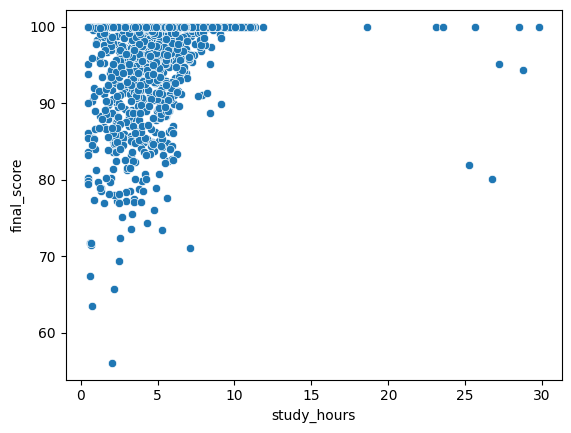

In [11]:
sns.scatterplot(data = df, x="study_hours", y="final_score")

<Axes: xlabel='internet_hours', ylabel='final_score'>

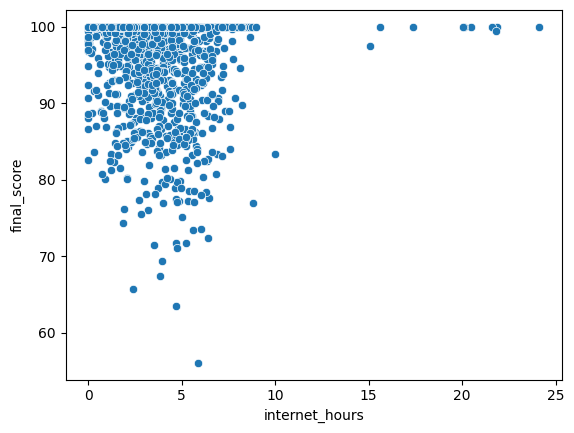

In [12]:
sns.scatterplot(data = df, x="internet_hours", y="final_score")

<Axes: xlabel='extracurricular_activity', ylabel='final_score'>

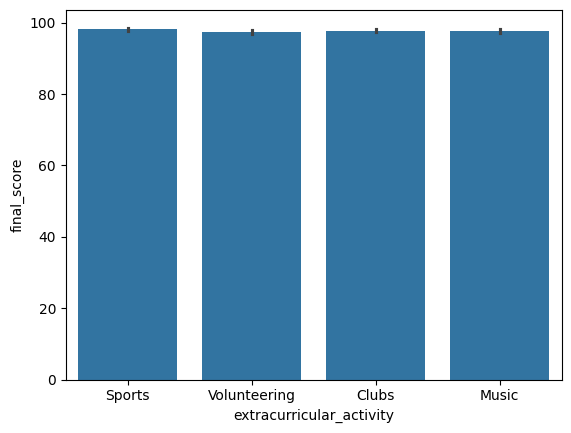

In [13]:
sns.barplot(data = df, x="extracurricular_activity", y="final_score")

<Axes: xlabel='study_method', ylabel='final_score'>

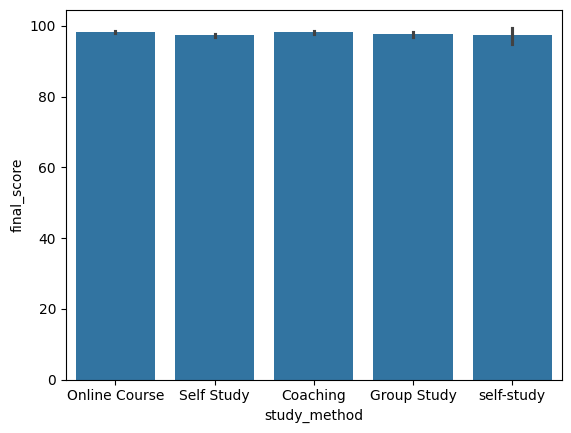

In [14]:
sns.barplot(data = df, x="study_method", y="final_score")

<Axes: >

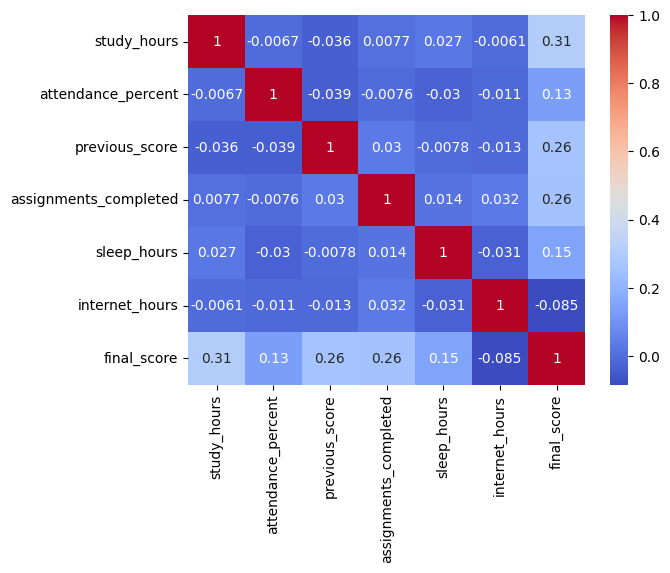

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

# Cleaning the Dataset

In [16]:
df.drop_duplicates()

,student_id,gender,study_hours,attendance_percent,previous_score,assignments_completed,sleep_hours,internet_hours,extracurricular_activity,study_method,parent_education,internet_access,final_score
0,STU12082,Male,6.27,87.6,82.5,5,7.19,NaN,NaN,Online Course,Postgraduate,No,100.0
1,STU10434,Female,1.84,90.7,82.3,7,8.33,2.19,NaN,Self Study,NaN,No,100.0
2,STU11725,NaN,7.75,69.7,74.4,8,7.32,2.12,NaN,Coaching,College,Yes,100.0
3,STU11252,Male,8.53,70.4,NaN,2,5.75,2.59,Sports,Coaching,College,Yes,100.0
4,STU10094,Male,5.34,86.6,68.0,4,7.50,1.26,Sports,Self Study,Postgraduate,Yes,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,STU11639,Female,5.52,65.9,78.5,4,7.05,6.93,NaN,Self Study,NaN,Yes,98.4
2508,STU11096,Male,7.95,100.0,82.2,10,7.11,4.67,NaN,Coaching,School,Yes,100.0
2509,STU11131,Male,3.71,86.7,66.0,9,6.08,4.40,NaN,Self Study,College,Yes,100.0
2510,STU11295,Other,6.02,60.3,52.0,3,6.99,1.50,Sports,Self Study,School,Yes,86.1


In [17]:
df["gender"].unique()

array(['Male', 'Female', nan, 'Other', 'male', ' FEMALE '], dtype=object)

In [18]:
df["gender"] = df["gender"].str.strip().str.capitalize()

In [19]:
df["gender"].unique()

array(['Male', 'Female', nan, 'Other'], dtype=object)

In [20]:
df.dropna(subset=["gender"], inplace=True)

In [21]:
df.shape

(2451, 13)

In [22]:
df.dropna(subset=["study_hours"], inplace=True)

In [23]:
for col in ["gender", "study_method", "parent_education", "internet_access"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
for col in ["study_hours", "attendance_percent", "previous_score", "sleep_hours", "internet_hours"]:
    df[col] = df[col].fillna(df[col].median())

In [25]:
df = df.drop(columns=["extracurricular_activity"])

In [27]:
df.sample(10)

,student_id,gender,study_hours,attendance_percent,previous_score,assignments_completed,sleep_hours,internet_hours,study_method,parent_education,internet_access,final_score
501,STU12253,Male,6.85,84.1,54.5,2,7.75,3.15,Self Study,School,Yes,100.0
2453,STU12450,Female,7.14,88.1,68.1,6,7.76,2.22,Self Study,Postgraduate,No,100.0
396,STU11773,Male,2.91,82.7,68.4,6,7.60,4.93,Self Study,College,Yes,96.5
824,STU10072,Female,3.23,85.7,67.3,2,6.58,5.54,Self Study,College,Yes,99.7
1508,STU10821,Female,4.54,58.7,62.6,9,6.02,5.28,Coaching,School,Yes,100.0
108,STU12332,Female,2.39,54.6,100.0,3,7.52,3.07,Online Course,College,Yes,95.1
188,STU11502,Male,4.25,88.7,88.3,9,7.32,2.45,Online Course,College,Yes,100.0
766,STU11707,Male,4.59,78.1,61.1,2,4.81,0.00,Self Study,School,Yes,86.7
2322,STU12192,Male,3.64,81.5,53.0,10,8.16,2.62,Group Study,Postgraduate,Yes,100.0
2477,STU11529,Male,1.23,76.0,85.8,7,6.80,6.04,Self Study,School,Yes,99.9


# Model Training

In [28]:
df = pd.get_dummies(df, columns=["gender", "study_method", "parent_education", "internet_access"], drop_first=True)

In [31]:
X = df.drop(columns=["final_score", "student_id"])
y = df["final_score"]

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)